In [1]:
#pip install nsepy

In [2]:
#pip install pandas

In [3]:
from Descriptive import Descriptive

In [4]:
obj=Descriptive()

In [5]:
#pip install yfinance

In [6]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [9]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-05-02,1449.075317,1459.721831,1446.679164,1454.460329,14512646
2024-05-03,1416.913086,1457.375095,1399.275803,1453.472210,17226958
2024-05-06,1402.610596,1422.841601,1401.103743,1418.395221,7394208
2024-05-07,1384.775635,1403.820987,1375.413559,1399.102859,14517472
2024-05-08,1401.647339,1415.875659,1380.848112,1380.848112,9439002
...,...,...,...,...,...
2025-10-01,1362.400757,1372.255218,1356.428371,1360.708629,12045916
2025-10-03,1357.125244,1365.287457,1350.655159,1356.926092,12842347


In [21]:
#Start date and end_date
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2024-05-01")
end_date = pd.to_datetime("2025-10-09") - timedelta(days=1) #Excluding last

#List of all dates
all_date = pd.date_range(start_date, end_date, freq='d')

In [25]:
print(len(all_date))

526


In [26]:
all_date

DatetimeIndex(['2024-05-01', '2024-05-02', '2024-05-03', '2024-05-04',
               '2024-05-05', '2024-05-06', '2024-05-07', '2024-05-08',
               '2024-05-09', '2024-05-10',
               ...
               '2025-09-29', '2025-09-30', '2025-10-01', '2025-10-02',
               '2025-10-03', '2025-10-04', '2025-10-05', '2025-10-06',
               '2025-10-07', '2025-10-08'],
              dtype='datetime64[ns]', length=526, freq='D')

In [27]:
dummyDate=stk_data

In [15]:
print(len(dummyDate))
print(len(all_date))

358
526


In [16]:
dummyDate.index = all_date[:len(dummyDate)]

In [29]:
dummyDate = stk_data.reindex(all_date)

In [30]:
dummyDate.index=all_date

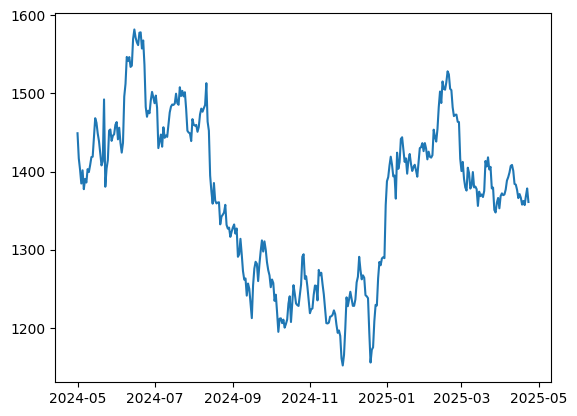

In [34]:
#DateIndex.index=pd.to_datetime(dataset["Date"],infer_datetime_format=True)
import matplotlib.pyplot as plt
plt.plot(stk_data['Close', 'RELIANCE.NS'])

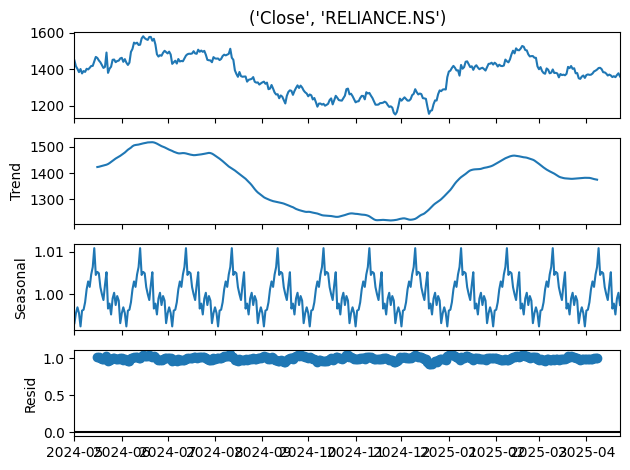

In [66]:
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
dummyDate = stk_data.copy()
result = seasonal_decompose(
    dummyDate[('Close', 'RELIANCE.NS')],model='multiplicative',period=30)
result.plot()
plt.show()

<Figure size 1600x500 with 0 Axes>

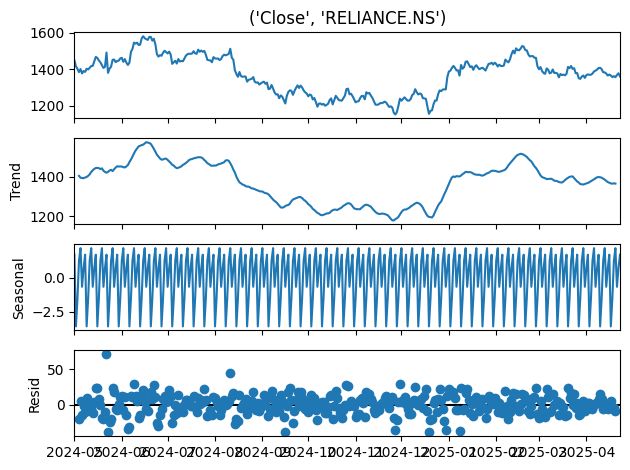

In [68]:
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate['Close', 'RELIANCE.NS'], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

In [42]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries,df,pollutant):
    plt.figure(figsize=(16,5))
    # Plot the data
    # ADF Test
    # Function to print out results in customised manner
    from statsmodels.tsa.stattools import adfuller
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
    ans=dfoutput
    print("Condition:")
    print("p-value<=0.05-->Accept Alternate Hypothesis")
    print("p-value>0.05-->Accept Null Hypothesis")
    if(ans['Test Statistic']<ans["Critical Value (1%)"] or ans['Test Statistic']<ans["Critical Value (5%)"] or ans['Test Statistic']<ans["Critical Value (10%)"] and ans["p-value"]<0.05):
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Reject null hypothesis:Non Stationarity")
        print("Accept Alternate hypothesis:Staionarity ")
        message="Stationarity based on ADH"
    else:
        print("Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis")
        print("Accept null hypothesis:Non Stationarity" )
        print("Reject Alternate hypothesis:Staionarity ")
        message="Non-stationarity based on ADH"
        
    plt.plot(df.index, df[pollutant], label = pollutant)
    plt.legend(loc='best')
    plt.title("{}_{}_2013 to 2021".format(message,pollutant))
    plt.savefig("{}_ADH.png".format(pollutant))
    plt.show()
    
    return message
    
# Call the function and run the test

Results of Dickey-Fuller Test:
Test Statistic                  -1.820336
p-value                          0.370413
#Lags Used                       0.000000
Number of Observations Used    357.000000
Critical Value (1%)             -3.448801
Critical Value (5%)             -2.869670
Critical Value (10%)            -2.571101
dtype: float64
Condition:
p-value<=0.05-->Accept Alternate Hypothesis
p-value>0.05-->Accept Null Hypothesis
Condition: statictic < any critical value and p-value <0.05 to reject null hypothsis
Accept null hypothesis:Non Stationarity
Reject Alternate hypothesis:Staionarity 


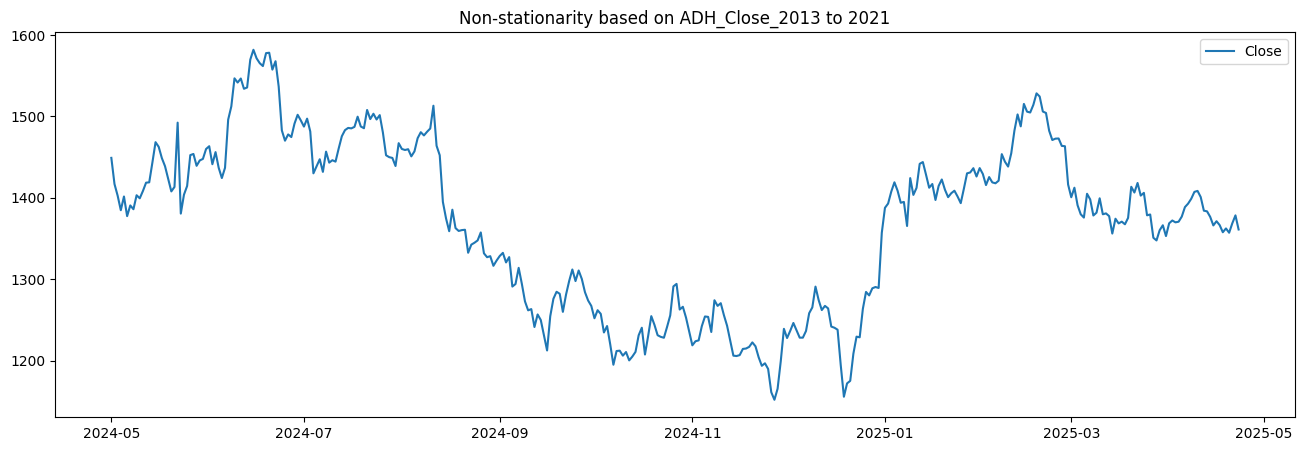

'Non-stationarity based on ADH'

In [45]:
adf_test(stk_data["Close"],stk_data,"Close")

In [48]:
print(stk_data.columns)

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


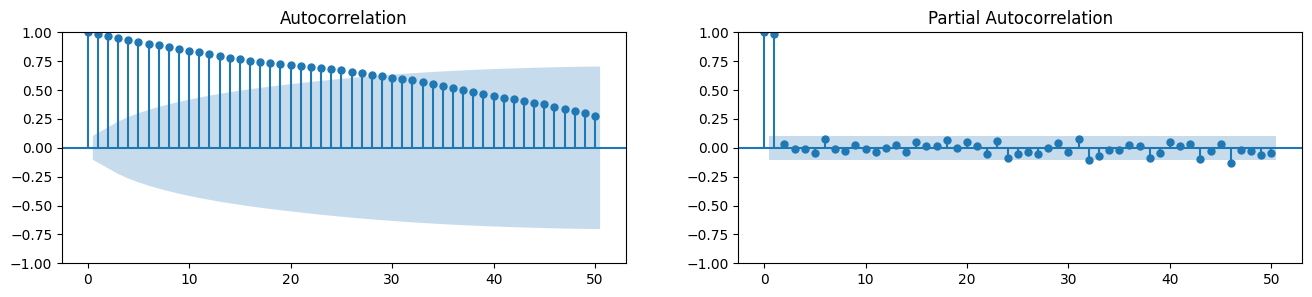

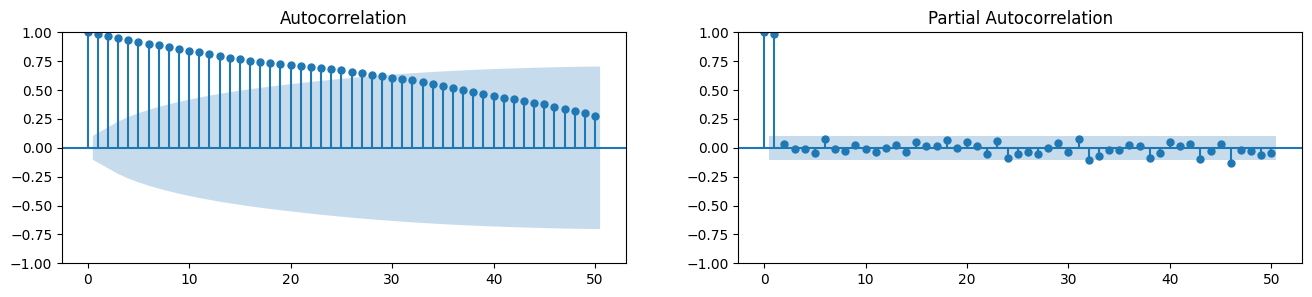

In [49]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
close = stk_data[('Close', 'RELIANCE.NS')]
plot_acf(close, lags=50, ax=axes[0])
plot_pacf(close, lags=50, ax=axes[1])

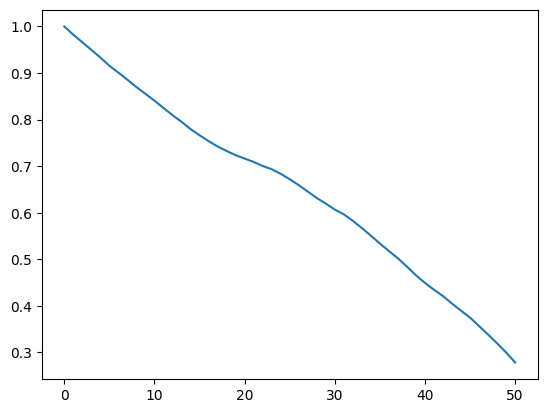

In [51]:
plt.plot(acf(stk_data[('Close', 'RELIANCE.NS')],nlags=50))

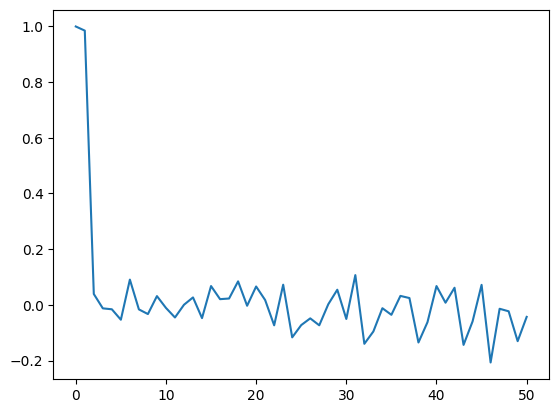

In [52]:
plt.plot(pacf(stk_data[('Close', 'RELIANCE.NS')],nlags=50))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

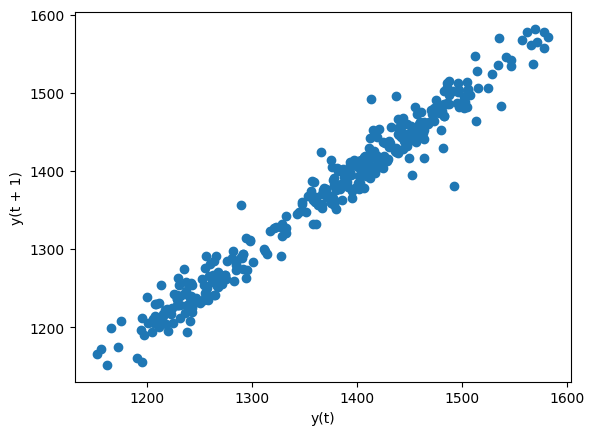

In [56]:
from pandas.plotting import lag_plot
lag_plot(stk_data['Close', 'RELIANCE.NS'],lag=1)

Forecastability

Apen small- Forecastability is possible

In [57]:
def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

In [63]:
import numpy as np
print(ApEn(stk_data['Close', 'RELIANCE.NS'], m=2, r=0.2*np.std(stk_data['Close', 'RELIANCE.NS'])))

0.5935674403441218


Spen Small-Forecastability is possible

In [64]:
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

In [65]:
print(SampEn(stk_data['Close', 'RELIANCE.NS'], m=2, r=0.2*np.std(stk_data['Close', 'RELIANCE.NS'])))

0.5566796045887531
